# Tarea 3 - Exploración y análisis de datos

## Pregunta de negocio 1 — Concentración de la contratación

###Rol: Análisis de datos Integrante: Jhoiner Javier Ramos Ramirez

¿En qué proveedores, modalidades y tipos de contrato se concentra la contratación de INVIAS, y existen patrones de concentración que requieran seguimiento por parte de la Dirección y los organismos de control?

In [118]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Preparación de la base

In [119]:
# Cargamos la base analítica construida en la Tarea 2

df = pd.read_csv(
    "../../Tarea 2/Pregunta 1/df_analitico_p1.csv",
    low_memory=False
)

df["fecha_de_firma"] = pd.to_datetime(
    df["fecha_de_firma"],
    errors="coerce"
)

print("Base analítica cargada correctamente.")
print("Registros:", f"{len(df):,}")
print("Variables:", df.shape[1])

Base analítica cargada correctamente.
Registros: 17,477
Variables: 19


In [120]:
# Separamos la población para análisis por cantidad y por valor

if "apto_conteo_p1" in df.columns:
    df_conteo = df[df["apto_conteo_p1"] == True].copy()
else:
    df_conteo = df.copy()

if "apto_valor_p1" in df.columns:
    df_valor = df[df["apto_valor_p1"] == True].copy()
else:
    df_valor = df_conteo[
        df_conteo["valor_del_contrato"] > 0
    ].copy()

print("Contratos para análisis por cantidad:", f"{len(df_conteo):,}")
print("Contratos para análisis por valor:", f"{len(df_valor):,}")

Contratos para análisis por cantidad: 17,477
Contratos para análisis por valor: 17,244


## 2. Configuración visual

In [121]:
# Definimos una paleta para las visualizaciones del proyecto

AZUL = "#2a78d6"
NARANJA = "#eb6834"
AQUA = "#1baf7a"
TINTA = "#0b0b0b"
GRIS = "#52514e"
GRIS_SUAVE = "#898781"
LINEA = "#e1e0d9"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 9,
    "axes.edgecolor": LINEA,
    "axes.labelcolor": GRIS,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.titlecolor": TINTA,
    "xtick.color": GRIS_SUAVE,
    "ytick.color": GRIS_SUAVE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white"
})

## 3. Caracterización general

In [122]:
# Resumimos las principales características de la contratación analizada

resumen_general = pd.Series({
    "Contratos": df_conteo["id_contrato"].nunique(),
    "Proveedores": df_conteo["proveedor_id"].nunique(),
    "Modalidades": df_conteo["modalidad_de_contratacion"].nunique(),
    "Tipos de contrato": df_conteo["tipo_de_contrato"].nunique(),
    "Valor total": df_valor["valor_del_contrato"].sum(),
    "Valor mediano": df_valor["valor_del_contrato"].median()
})

resumen_general

,0
Contratos,"17,477.00"
Proveedores,"8,748.00"
Modalidades,11.00
Tipos de contrato,14.00
Valor total,"34,853,967,177,693.68"
Valor mediano,"77,675,417.50"


## 4. Distribución del valor contractual

In [123]:
# Calculamos estadísticos descriptivos del valor de los contratos

df_valor["valor_del_contrato"].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

,valor_del_contrato
count,"17,244.00"
mean,"2,021,222,870.43"
std,"23,226,735,389.88"
min,0.10
25%,"42,933,333.75"
50%,"77,675,417.50"
75%,"200,926,249.75"
90%,"1,124,941,886.50"
95%,"2,663,120,872.75"
99%,"27,711,843,590.87"


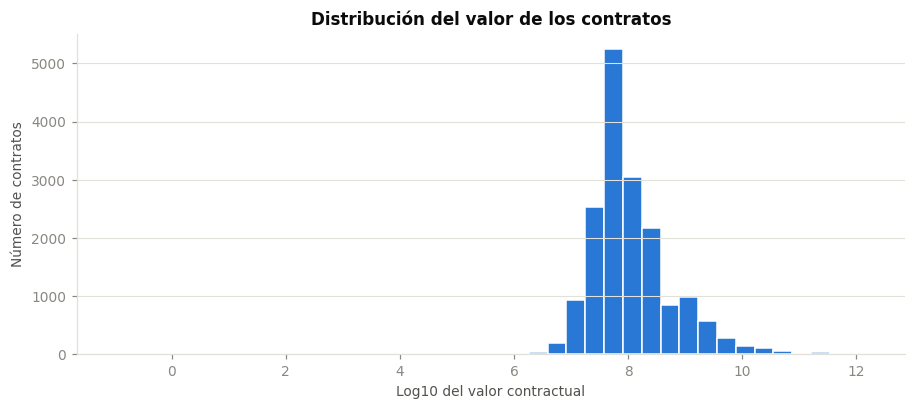

In [124]:
# Analizamos la distribución del valor contractual en escala logarítmica

valor_log = np.log10(df_valor["valor_del_contrato"])

fig, ax = plt.subplots(figsize=(8.4, 3.8))

ax.hist(valor_log,bins=40,color=AZUL,edgecolor="white")

ax.set_title("Distribución del valor de los contratos")
ax.set_xlabel("Log10 del valor contractual")
ax.set_ylabel("Número de contratos")

ax.grid(axis="y", color=LINEA, linewidth=0.7)

plt.tight_layout()
plt.show()

## 5. Concentración por proveedor

In [125]:
# Agregamos número de contratos y valor contratado por proveedor

proveedores = (df_valor.groupby(["proveedor_id", "proveedor_etiqueta"])
    .agg(contratos=("id_contrato", "nunique"),valor_contratado=("valor_del_contrato", "sum")).reset_index())

proveedores["participacion_valor_pct"] = (
    proveedores["valor_contratado"]
    / proveedores["valor_contratado"].sum()
    * 100)

proveedores = (
    proveedores
    .sort_values("valor_contratado", ascending=False)
    .reset_index(drop=True))

proveedores["participacion_acumulada_pct"] = (
    proveedores["participacion_valor_pct"].cumsum())

proveedores.head(10)

,proveedor_id,proveedor_etiqueta,contratos,valor_contratado,participacion_valor_pct,participacion_acumulada_pct
0,NOMBRE_UNION TEMPORAL PEAJES NACIONALES,UNION TEMPORAL PEAJES NACIONALES,1,"1,581,452,956,192.21",4.54,4.54
1,DOC_890922447,CONSTRUCCIONES EL CONDOR S.A,2,"957,773,458,945.00",2.75,7.29
2,NOMBRE_CONSORCIO VIADUCTO CIÉNAGA DEL MAGDALENA,CONSORCIO VIADUCTO CIÉNAGA DEL MAGDALENA,1,"657,176,378,088.00",1.89,9.17
3,NOMBRE_CONSORCIO VARIANTE ORIENTAL 057,CONSORCIO VARIANTE ORIENTAL 057,1,"650,399,558,495.00",1.87,11.04
4,NOMBRE_CONSORCIO SAN FRANCISCO,CONSORCIO SAN FRANCISCO,1,"610,461,362,068.00",1.75,12.79
5,NOMBRE_CONSORCIO VIAL MHC 063,CONSORCIO VIAL MHC 063,1,"593,383,681,529.00",1.70,14.49
6,DOC_890801052,GOBERNACION DE CALDAS,4,"590,653,185,628.00",1.69,16.19
7,NOMBRE_CONSORCIO LEJIA 052,CONSORCIO LEJIA 052,1,"511,743,141,447.00",1.47,17.65
8,NOMBRE_CONSORCIO ANTIOQUIA AL MAR,CONSORCIO ANTIOQUIA AL MAR,1,"496,344,941,711.00",1.42,19.08
9,NOMBRE_CONSORCIO GPS INFRAESTRUCTURA,CONSORCIO GPS INFRAESTRUCTURA,1,"454,775,921,790.00",1.30,20.38


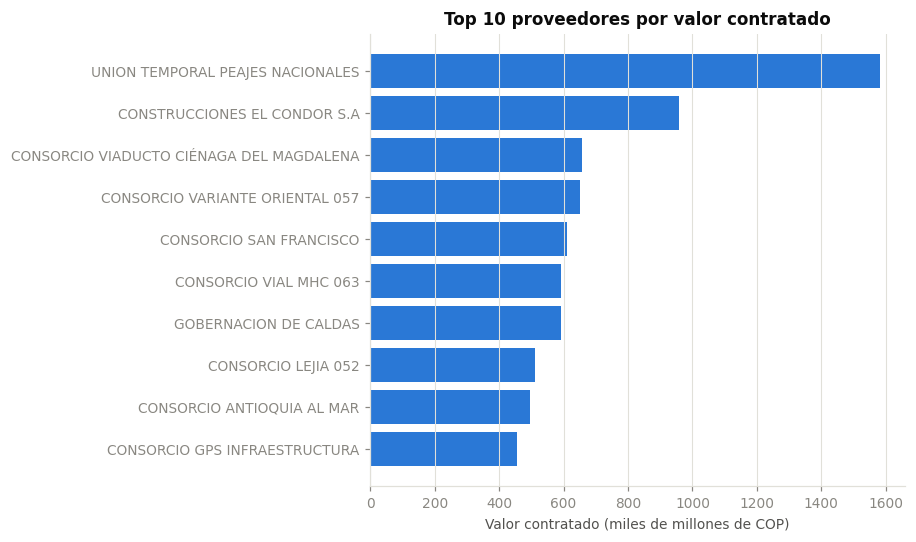

In [126]:
# Visualizamos los diez proveedores con mayor valor contratado

top10 = proveedores.head(10).sort_values("valor_contratado")

fig, ax = plt.subplots(figsize=(8.4, 5))

ax.barh(
    top10["proveedor_etiqueta"],
    top10["valor_contratado"] / 1e9,
    color=AZUL)

ax.set_title("Top 10 proveedores por valor contratado")
ax.set_xlabel("Valor contratado (miles de millones de COP)")

ax.grid(axis="x", color=LINEA, linewidth=0.7)

plt.tight_layout()
plt.show()

### 5.1 Curva de concentración

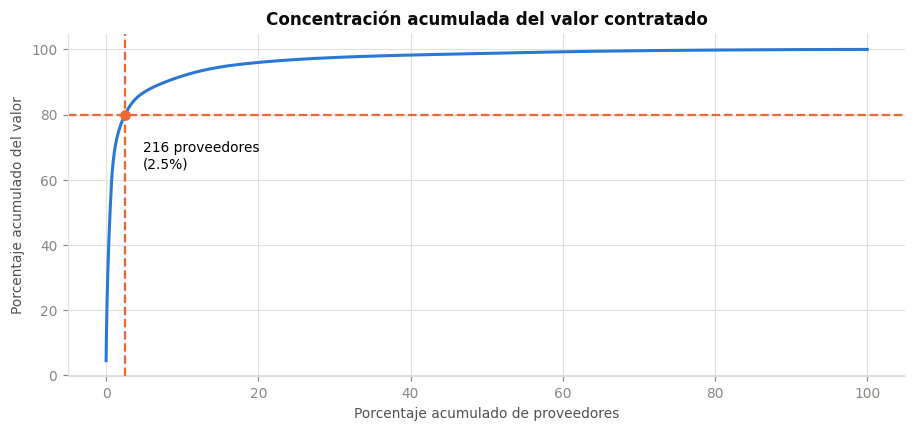

216 proveedores, equivalentes al 2.49% del total, acumulan al menos el 80% del valor contratado.


In [127]:
# Calculamos cuántos proveedores se necesitan para alcanzar el 80% del valor

proveedores_80 = (proveedores["participacion_acumulada_pct"].lt(80).sum()+ 1)

porcentaje_proveedores_80 = (
    proveedores_80
    / len(proveedores)
    * 100)

# Calculamos el porcentaje acumulado de proveedores

proveedores["porcentaje_proveedores"] = (np.arange(1, len(proveedores) + 1)/ len(proveedores)* 100)

# Graficamos la concentración acumulada

fig, ax = plt.subplots(figsize=(8.4, 4))

ax.plot(
    proveedores["porcentaje_proveedores"],
    proveedores["participacion_acumulada_pct"],
    color=AZUL,
    linewidth=2)

ax.axhline(
    80,
    color=NARANJA,
    linestyle="--",
    linewidth=1.5)

ax.axvline(
    porcentaje_proveedores_80,
    color=NARANJA,
    linestyle="--",
    linewidth=1.5)

ax.scatter(
    porcentaje_proveedores_80,
    80,
    color=NARANJA,
    zorder=5)

ax.annotate(
    f"{proveedores_80} proveedores\n({porcentaje_proveedores_80:.1f}%)",
    xy=(porcentaje_proveedores_80, 80),
    xytext=(12, -35),
    textcoords="offset points")

ax.set_title("Concentración acumulada del valor contratado")
ax.set_xlabel("Porcentaje acumulado de proveedores")
ax.set_ylabel("Porcentaje acumulado del valor")

ax.grid(color=LINEA, linewidth=0.7)

plt.tight_layout()
plt.show()

print(
    f"{proveedores_80} proveedores, equivalentes al "
    f"{porcentaje_proveedores_80:.2f}% del total, "
    "acumulan al menos el 80% del valor contratado.")

### 5.2 Indicadores de concentración

In [128]:
# Calculamos CR1, CR5, CR10 y HHI por valor contratado

participaciones = proveedores["participacion_valor_pct"]

cr1 = participaciones.head(1).sum()
cr5 = participaciones.head(5).sum()
cr10 = participaciones.head(10).sum()

hhi = (participaciones ** 2).sum()

indicadores_concentracion = pd.DataFrame({"Indicador": ["CR1","CR5","CR10","HHI"],"Valor": [cr1,cr5,cr10,hhi]})

indicadores_concentracion

,Indicador,Valor
0,CR1,4.54
1,CR5,12.79
2,CR10,20.38
3,HHI,85.04


## 6. Número de contratos frente a valor contratado

In [129]:
# Construimos la información por número de contratos

conteo_proveedores = (df_conteo.groupby(["proveedor_id", "proveedor_etiqueta"]).agg(numero_contratos=("id_contrato", "nunique")).reset_index())

proveedores_comparacion = proveedores.merge(conteo_proveedores,on=["proveedor_id", "proveedor_etiqueta"],how="left")

proveedores_comparacion.head()

,proveedor_id,proveedor_etiqueta,contratos,valor_contratado,participacion_valor_pct,participacion_acumulada_pct,porcentaje_proveedores,numero_contratos
0,NOMBRE_UNION TEMPORAL PEAJES NACIONALES,UNION TEMPORAL PEAJES NACIONALES,1,"1,581,452,956,192.21",4.54,4.54,0.01,1
1,DOC_890922447,CONSTRUCCIONES EL CONDOR S.A,2,"957,773,458,945.00",2.75,7.29,0.02,2
2,NOMBRE_CONSORCIO VIADUCTO CIÉNAGA DEL MAGDALENA,CONSORCIO VIADUCTO CIÉNAGA DEL MAGDALENA,1,"657,176,378,088.00",1.89,9.17,0.03,1
3,NOMBRE_CONSORCIO VARIANTE ORIENTAL 057,CONSORCIO VARIANTE ORIENTAL 057,1,"650,399,558,495.00",1.87,11.04,0.05,1
4,NOMBRE_CONSORCIO SAN FRANCISCO,CONSORCIO SAN FRANCISCO,1,"610,461,362,068.00",1.75,12.79,0.06,1


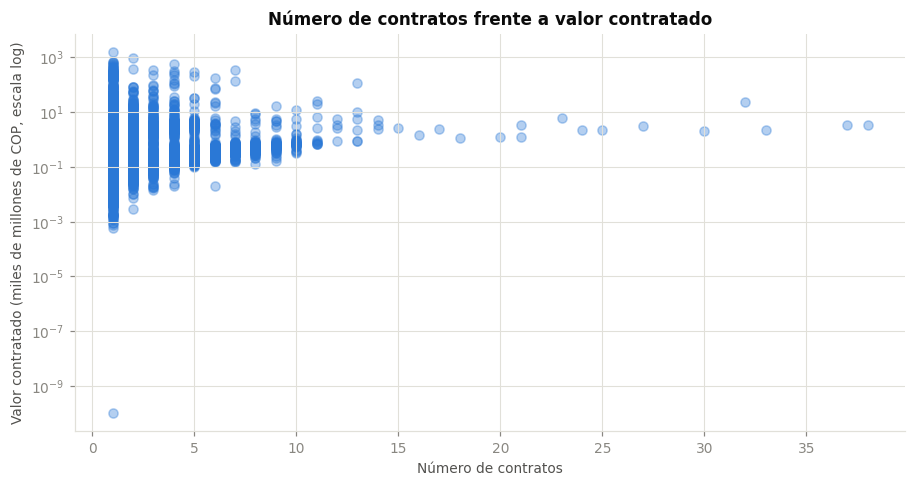

In [130]:
# Comparamos el número de contratos con el valor contratado
# utilizando escala logarítmica para facilitar la visualización

fig, ax = plt.subplots(figsize=(8.4, 4.5))

ax.scatter(
    proveedores_comparacion["numero_contratos"],
    proveedores_comparacion["valor_contratado"] / 1e9,
    color=AZUL,
    alpha=0.35)

ax.set_yscale("log")

ax.set_title("Número de contratos frente a valor contratado")
ax.set_xlabel("Número de contratos")
ax.set_ylabel("Valor contratado (miles de millones de COP, escala log)")

ax.grid(color=LINEA, linewidth=0.7)

plt.tight_layout()
plt.show()

### 6.1 Relación estadística

In [131]:
# Evaluamos la relación entre cantidad de contratos y valor contratado

rho, p_valor = stats.spearmanr(
    proveedores_comparacion["numero_contratos"],
    proveedores_comparacion["valor_contratado"])

# Clasificamos la intensidad de la relación

if abs(rho) < 0.30:
    intensidad = "débil"
elif abs(rho) < 0.50:
    intensidad = "moderada"
else:
    intensidad = "fuerte"

direccion = "positiva" if rho > 0 else "negativa"

print(f"Correlación de Spearman: {rho:.3f}")

if p_valor < 0.001:
    print("p-valor: < 0.001")
else:
    print(f"p-valor: {p_valor:.4f}")

print(
    f"La relación es {direccion} y {intensidad}.")

if p_valor < 0.05:
    print(
        "La asociación entre número de contratos y valor contratado "
        "es estadísticamente significativa.")
else:
    print(
        "No se encuentra una asociación estadísticamente significativa.")

Correlación de Spearman: 0.186
p-valor: < 0.001
La relación es positiva y débil.
La asociación entre número de contratos y valor contratado es estadísticamente significativa.


## 7. Concentración por modalidad de contratación

In [132]:
# Calculamos la cantidad de contratos por modalidad

modalidad_conteo = (
    df_conteo
    .groupby("modalidad_de_contratacion")
    .agg(
        contratos=("id_contrato", "nunique"))
    .reset_index())

# Calculamos el valor contratado por modalidad

modalidad_valor = (
    df_valor
    .groupby("modalidad_de_contratacion")
    .agg(
        valor_contratado=("valor_del_contrato", "sum"),
        valor_mediano=("valor_del_contrato", "median")
    )
    .reset_index())

# Unimos ambas dimensiones

modalidades = modalidad_conteo.merge(
    modalidad_valor,
    on="modalidad_de_contratacion",
    how="outer")

modalidades["participacion_contratos_pct"] = (
    modalidades["contratos"]
    / modalidades["contratos"].sum()
    * 100)

modalidades["participacion_valor_pct"] = (
    modalidades["valor_contratado"]
    / modalidades["valor_contratado"].sum()
    * 100)

modalidades = modalidades.sort_values(
    "participacion_valor_pct",
    ascending=False)

modalidades

,modalidad_de_contratacion,contratos,valor_contratado,valor_mediano,participacion_contratos_pct,participacion_valor_pct
6,Licitación pública Obra Publica,669,"19,729,894,901,367.33","1,851,041,462.00",3.83,56.61
2,Contratación directa,12261,"7,021,014,576,764.67","63,483,333.00",70.16,20.14
5,Licitación pública,359,"3,625,157,861,886.92","970,786,415.00",2.05,10.40
0,Concurso de méritos abierto,1156,"2,828,293,400,894.16","797,230,369.00",6.61,8.11
1,Contratación Directa (con ofertas),21,"704,690,133,455.80","4,061,275,908.00",0.12,2.02
9,Selección Abreviada de Menor Cuantía,598,"305,356,099,152.67","392,968,087.00",3.42,0.88
8,Seleccion Abreviada Menor Cuantia Sin Manifest...,49,"287,041,427,793.00","1,193,747,661.00",0.28,0.82
7,Mínima cuantía,2276,"238,064,981,431.77","69,087,039.20",13.02,0.68
10,Selección abreviada subasta inversa,84,"108,998,419,897.07","600,000,000.00",0.48,0.31
3,Contratación régimen especial,3,"5,455,375,050.19","2,727,687,525.09",0.02,0.02


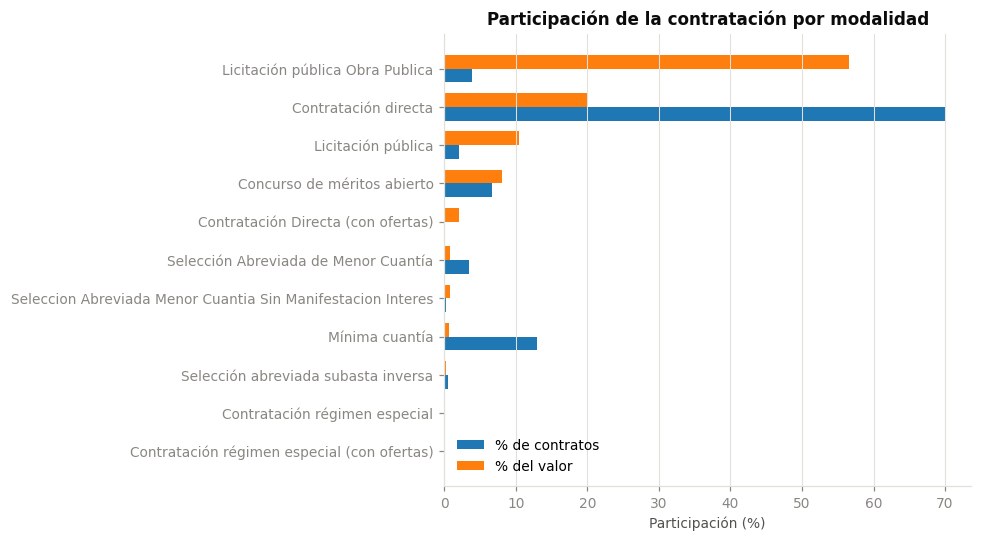

In [133]:
# Comparamos la participación en cantidad de contratos y en valor contratado

grafica_modalidades = modalidades.sort_values(
    "participacion_valor_pct",
    ascending=True)

y = np.arange(len(grafica_modalidades))
altura = 0.36

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    y - altura / 2,
    grafica_modalidades["participacion_contratos_pct"],
    height=altura,
    label="% de contratos")

ax.barh(
    y + altura / 2,
    grafica_modalidades["participacion_valor_pct"],
    height=altura,
    label="% del valor")

ax.set_yticks(y)
ax.set_yticklabels(
    grafica_modalidades["modalidad_de_contratacion"])

ax.set_title("Participación de la contratación por modalidad")
ax.set_xlabel("Participación (%)")

ax.legend(frameon=False)

ax.grid(
    axis="x",
    color=LINEA,
    linewidth=0.7)

plt.tight_layout()
plt.show()

### 7.1 Distribución del valor por modalidad

In [134]:
# Seleccionamos las modalidades con mayor número de contratos

modalidades_principales = (
    df_valor["modalidad_de_contratacion"]
    .value_counts()
    .head(6)
    .index)

datos_modalidad = df_valor[
    df_valor["modalidad_de_contratacion"].isin(
        modalidades_principales)].copy()

datos_modalidad["log_valor"] = np.log10(
    datos_modalidad["valor_del_contrato"])

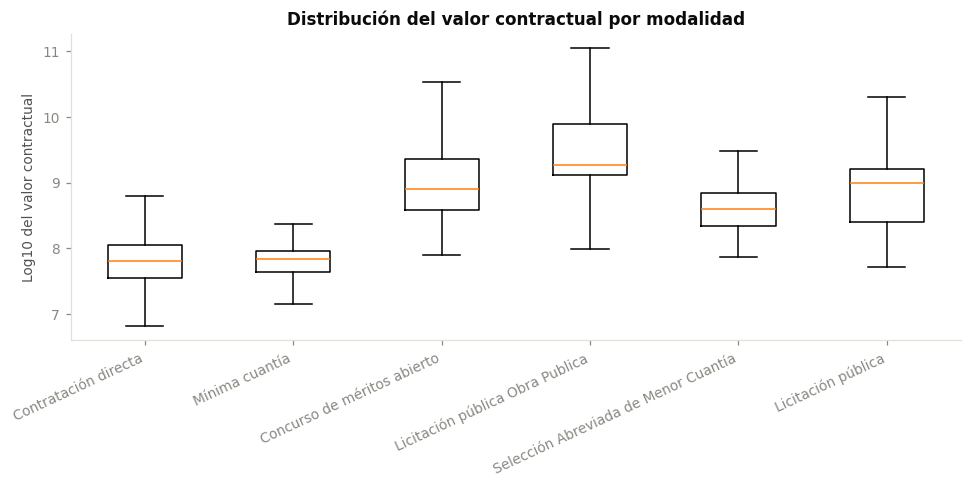

In [135]:
# Comparamos la distribución del valor entre modalidades

grupos = [
    datos_modalidad.loc[
        datos_modalidad["modalidad_de_contratacion"] == modalidad,
        "log_valor"]
    for modalidad in modalidades_principales]

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.boxplot(
    grupos,
    tick_labels=modalidades_principales,
    showfliers=False
)

ax.set_title("Distribución del valor contractual por modalidad")
ax.set_ylabel("Log10 del valor contractual")

plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

### 7.2 Prueba de diferencias entre modalidades

In [136]:
# Evaluamos si el valor contractual difiere entre modalidades

grupos_kw = [
    grupo["valor_del_contrato"].values
    for _, grupo in df_valor.groupby(
        "modalidad_de_contratacion"
    )
    if len(grupo) >= 30
]

h_modalidad, p_modalidad = stats.kruskal(
    *grupos_kw
)

print(f"Kruskal-Wallis H: {h_modalidad:.2f}")

if p_modalidad < 0.001:
    print("p-valor: < 0.001")
else:
    print(f"p-valor: {p_modalidad:.4f}")

if p_modalidad < 0.05:
    print(
        "Se rechaza H0: existen diferencias estadísticamente "
        "significativas en el valor contractual entre modalidades."
    )
else:
    print(
        "No se encuentran diferencias estadísticamente "
        "significativas entre modalidades."
    )

Kruskal-Wallis H: 5648.42
p-valor: < 0.001
Se rechaza H0: existen diferencias estadísticamente significativas en el valor contractual entre modalidades.


## 8. Concentración por tipo de contrato

In [137]:
# Calculamos la cantidad de contratos por tipo de contrato

tipo_conteo = (
    df_conteo
    .groupby("tipo_de_contrato")
    .agg(
        contratos=("id_contrato", "nunique")
    )
    .reset_index()
)

# Calculamos el valor contratado por tipo de contrato

tipo_valor = (
    df_valor
    .groupby("tipo_de_contrato")
    .agg(
        valor_contratado=("valor_del_contrato", "sum"),
        valor_mediano=("valor_del_contrato", "median")
    )
    .reset_index()
)

# Unimos ambas dimensiones

tipos = tipo_conteo.merge(
    tipo_valor,
    on="tipo_de_contrato",
    how="outer"
)

tipos["participacion_contratos_pct"] = (
    tipos["contratos"]
    / tipos["contratos"].sum()
    * 100
)

tipos["participacion_valor_pct"] = (
    tipos["valor_contratado"]
    / tipos["valor_contratado"].sum()
    * 100
)

tipos = tipos.sort_values(
    "participacion_valor_pct",
    ascending=False
)

tipos

,tipo_de_contrato,contratos,valor_contratado,valor_mediano,participacion_contratos_pct,participacion_valor_pct
9,Obra,2700,"23,105,077,029,381.88","581,312,092.00",15.45,66.29
10,Otro,1977,"5,252,730,012,364.48","200,995,632.00",11.31,15.07
8,Interventoría,1394,"2,253,083,477,945.66","251,512,791.50",7.98,6.46
5,Concesión,2,"1,782,943,292,527.21","891,471,646,263.60",0.01,5.12
11,Prestación de servicios,10282,"1,140,372,378,089.40","53,350,000.00",58.83,3.27
6,Consultoría,472,"626,701,458,072.60","480,479,517.00",2.70,1.80
0,Acuerdo Marco de Precios,5,"409,847,336,369.68","78,877,054,081.68",0.03,1.18
13,Suministros,488,"163,220,724,817.47","80,654,505.50",2.79,0.47
1,Arrendamiento de inmuebles,26,"53,534,270,356.11","33,777,620.50",0.15,0.15
4,Compraventa,66,"41,437,032,258.00","93,817,808.00",0.38,0.12


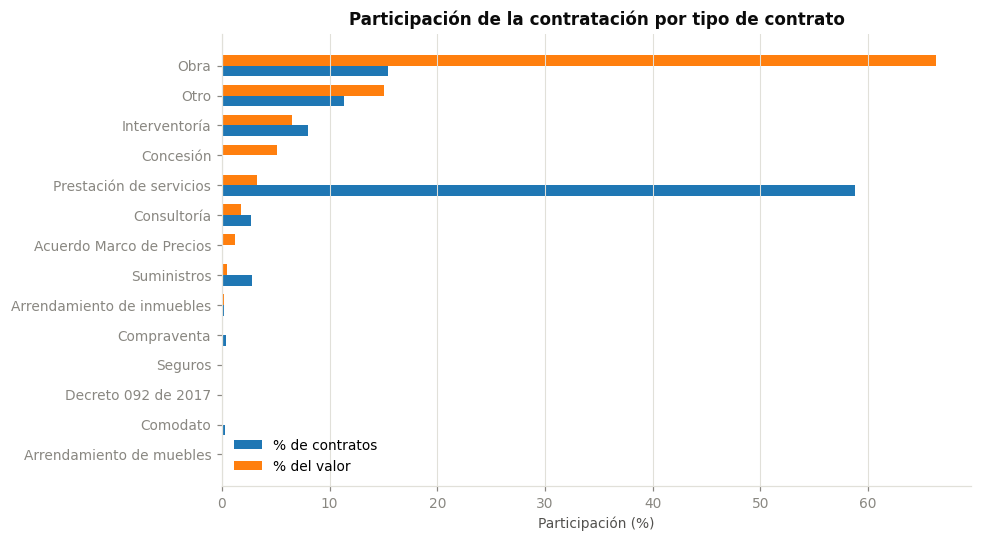

In [138]:
# Comparamos participación en cantidad y valor por tipo de contrato

grafica_tipos = tipos.sort_values(
    "participacion_valor_pct",
    ascending=True
)

y = np.arange(len(grafica_tipos))
altura = 0.36

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    y - altura / 2,
    grafica_tipos["participacion_contratos_pct"],
    height=altura,
    label="% de contratos"
)

ax.barh(
    y + altura / 2,
    grafica_tipos["participacion_valor_pct"],
    height=altura,
    label="% del valor"
)

ax.set_yticks(y)
ax.set_yticklabels(
    grafica_tipos["tipo_de_contrato"]
)

ax.set_title("Participación de la contratación por tipo de contrato")
ax.set_xlabel("Participación (%)")

ax.legend(frameon=False)

ax.grid(
    axis="x",
    color=LINEA,
    linewidth=0.7
)

plt.tight_layout()
plt.show()

### 8.1 Distribución del valor por tipo de contrato

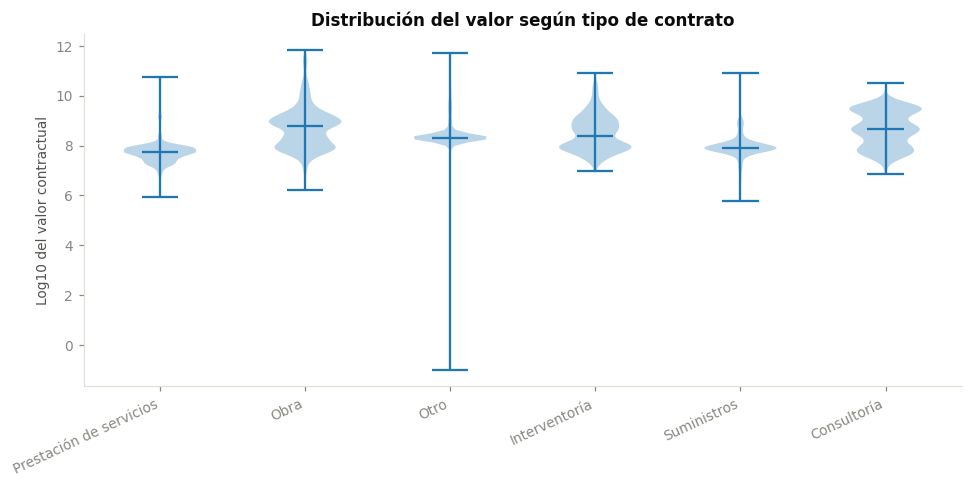

In [139]:
# Seleccionamos los tipos de contrato más frecuentes

tipos_principales = (
    df_valor["tipo_de_contrato"]
    .value_counts()
    .head(6)
    .index
)

datos_tipo = df_valor[
    df_valor["tipo_de_contrato"].isin(
        tipos_principales
    )
].copy()

datos_tipo["log_valor"] = np.log10(
    datos_tipo["valor_del_contrato"]
)

grupos_tipo = [
    datos_tipo.loc[
        datos_tipo["tipo_de_contrato"] == tipo,
        "log_valor"
    ].values
    for tipo in tipos_principales
]

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.violinplot(
    grupos_tipo,
    showmedians=True
)

ax.set_xticks(
    range(1, len(tipos_principales) + 1)
)

ax.set_xticklabels(
    tipos_principales,
    rotation=25,
    ha="right"
)

ax.set_title("Distribución del valor según tipo de contrato")
ax.set_ylabel("Log10 del valor contractual")

plt.tight_layout()
plt.show()

### 8.2 Prueba de diferencias entre tipos de contrato

In [140]:
# Evaluamos si el valor contractual difiere según el tipo de contrato

grupos_kw_tipo = [
    grupo["valor_del_contrato"].values
    for _, grupo in df_valor.groupby(
        "tipo_de_contrato"
    )
    if len(grupo) >= 30
]

h_tipo, p_tipo = stats.kruskal(
    *grupos_kw_tipo
)

print(f"Kruskal-Wallis H: {h_tipo:.2f}")

if p_tipo < 0.001:
    print("p-valor: < 0.001")
else:
    print(f"p-valor: {p_tipo:.4f}")

if p_tipo < 0.05:
    print(
        "Se rechaza H0: existen diferencias estadísticamente "
        "significativas en el valor contractual entre tipos de contrato."
    )
else:
    print(
        "No se encuentran diferencias estadísticamente "
        "significativas entre tipos de contrato."
    )

Kruskal-Wallis H: 7090.64
p-valor: < 0.001
Se rechaza H0: existen diferencias estadísticamente significativas en el valor contractual entre tipos de contrato.


## 9. Relación entre modalidad y tipo de contrato

In [141]:
# Construimos una matriz con la distribución del valor por modalidad y tipo

top_modalidades = (
    df_valor["modalidad_de_contratacion"]
    .value_counts()
    .head(6)
    .index
)

top_tipos = (
    df_valor["tipo_de_contrato"]
    .value_counts()
    .head(6)
    .index
)

matriz = (
    df_valor[
        df_valor["modalidad_de_contratacion"].isin(top_modalidades)
        & df_valor["tipo_de_contrato"].isin(top_tipos)
    ]
    .pivot_table(
        index="modalidad_de_contratacion",
        columns="tipo_de_contrato",
        values="valor_del_contrato",
        aggfunc="sum",
        fill_value=0
    )
)

# Convertimos cada fila a porcentaje

matriz_pct = matriz.div(
    matriz.sum(axis=1),
    axis=0
) * 100

matriz_pct.round(1)

tipo_de_contrato,Consultoría,Interventoría,Obra,Otro,Prestación de servicios,Suministros
modalidad_de_contratacion,,,,,,
Concurso de méritos abierto,21.90,78.10,0.00,0.00,0.00,0.00
Contratación directa,0.00,0.00,25.70,65.10,9.10,0.10
Licitación pública,0.00,0.00,72.00,0.00,28.00,0.00
Licitación pública Obra Publica,0.00,0.00,100.00,0.00,0.00,0.00
Mínima cuantía,3.50,18.30,22.90,2.70,4.30,48.30
Selección Abreviada de Menor Cuantía,0.00,0.00,81.80,0.70,9.80,7.60


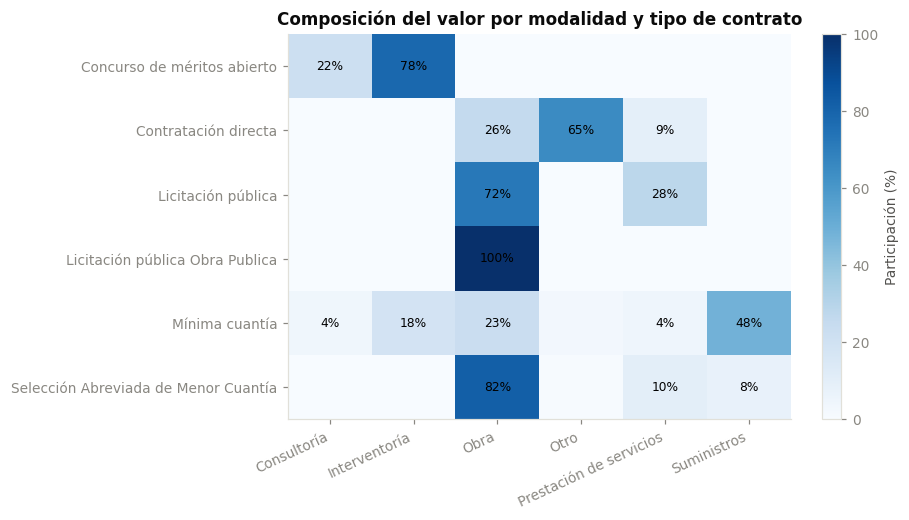

In [142]:
# Visualizamos la composición del valor mediante un mapa de calor

fig, ax = plt.subplots(figsize=(8.5, 4.8))

im = ax.imshow(
    matriz_pct.values,
    cmap="Blues",
    aspect="auto",
    vmin=0,
    vmax=100
)

ax.set_xticks(
    range(len(matriz_pct.columns))
)

ax.set_xticklabels(
    matriz_pct.columns,
    rotation=25,
    ha="right"
)

ax.set_yticks(
    range(len(matriz_pct.index))
)

ax.set_yticklabels(
    matriz_pct.index
)

for i in range(matriz_pct.shape[0]):
    for j in range(matriz_pct.shape[1]):
        valor = matriz_pct.iloc[i, j]

        if valor >= 3:
            ax.text(
                j,
                i,
                f"{valor:.0f}%",
                ha="center",
                va="center",
                fontsize=8
            )

ax.set_title(
    "Composición del valor por modalidad y tipo de contrato"
)

fig.colorbar(
    im,
    ax=ax,
    label="Participación (%)"
)

plt.tight_layout()
plt.show()

### 9.1 Asociación entre modalidad y tipo de contrato

In [143]:
# Evaluamos estadísticamente la asociación entre modalidad y tipo

tabla_contingencia = pd.crosstab(
    df_conteo["modalidad_de_contratacion"],
    df_conteo["tipo_de_contrato"]
)

chi2, p_chi, gl, esperados = stats.chi2_contingency(
    tabla_contingencia
)

n = tabla_contingencia.values.sum()

v_cramer = np.sqrt(
    chi2
    / (
        n
        * (
            min(tabla_contingencia.shape) - 1
        )
    )
)

print(f"Chi-cuadrado: {chi2:.2f}")

if p_chi < 0.001:
    print("p-valor: < 0.001")
else:
    print(f"p-valor: {p_chi:.4f}")

print(f"V de Cramér: {v_cramer:.3f}")

if p_chi < 0.05:
    print(
        "Se rechaza H0: existe una asociación estadísticamente "
        "significativa entre modalidad y tipo de contrato."
    )
else:
    print(
        "No se encuentra una asociación estadísticamente significativa "
        "entre modalidad y tipo de contrato."
    )

Chi-cuadrado: 38727.48
p-valor: < 0.001
V de Cramér: 0.471
Se rechaza H0: existe una asociación estadísticamente significativa entre modalidad y tipo de contrato.


## 10. Evolución de la concentración en el tiempo

In [144]:
# Calculamos la concentración por proveedor para cada año

resultados_anuales = []

for anio, grupo in df_valor.groupby("anio_firma"):

    proveedor_anual = (
        grupo
        .groupby("proveedor_id")[
            "valor_del_contrato"
        ]
        .sum()
        .sort_values(ascending=False)
    )

    participacion = (
        proveedor_anual
        / proveedor_anual.sum()
        * 100
    )

    resultados_anuales.append({
        "anio_firma": anio,
        "contratos": grupo["id_contrato"].nunique(),
        "proveedores": grupo["proveedor_id"].nunique(),
        "valor_contratado": grupo["valor_del_contrato"].sum(),
        "CR1": participacion.head(1).sum(),
        "CR5": participacion.head(5).sum(),
        "CR10": participacion.head(10).sum(),
        "HHI": (participacion ** 2).sum()
    })

concentracion_anual = pd.DataFrame(
    resultados_anuales
).sort_values("anio_firma")

concentracion_anual

,anio_firma,contratos,proveedores,valor_contratado,CR1,CR5,CR10,HHI
0,2017,47,39,"2,460,920,503.48",19.95,44.60,60.98,682.73
1,2018,1070,907,"1,664,193,669,325.44",18.93,60.86,75.88,882.61
2,2019,1253,875,"1,648,932,483,835.79",13.32,54.26,64.82,697.39
3,2020,2037,1707,"4,124,798,592,446.54",5.44,25.06,40.16,217.87
4,2021,2020,1717,"14,451,320,834,221.10",10.94,29.99,45.17,319.95
5,2022,1504,1340,"2,130,403,269,382.45",30.85,61.92,67.30,"1,313.43"
6,2023,3871,2943,"1,560,645,661,846.44",5.71,18.68,28.01,134.27
7,2024,2952,2606,"2,559,604,399,877.13",8.65,27.92,36.54,227.63
8,2025,1613,1438,"922,526,077,051.94",17.76,39.56,55.53,513.97
9,2026,877,868,"5,789,081,269,203.37",11.23,35.26,59.13,504.10


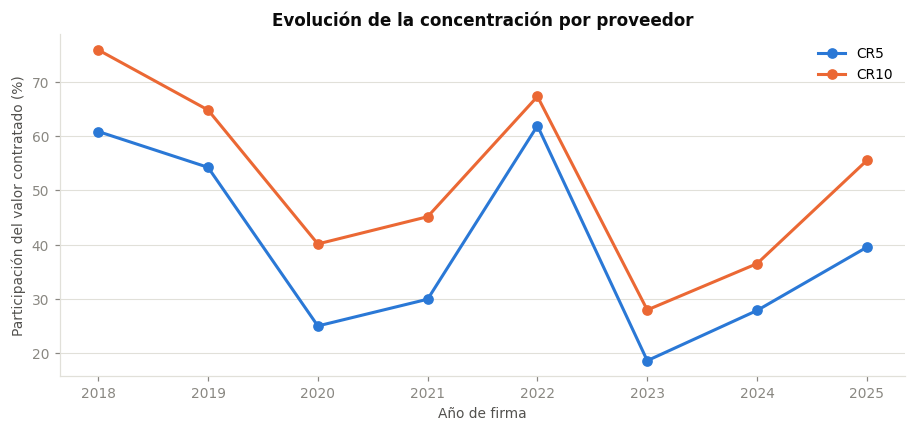

La gráfica utiliza 2018-2025 para comparar únicamente años completos.


In [145]:
# Para analizar tendencias utilizamos únicamente años completos

concentracion_tendencia = concentracion_anual[
    concentracion_anual["anio_firma"].between(2018, 2025)
].copy()

# Visualizamos la evolución de CR5 y CR10

fig, ax = plt.subplots(figsize=(8.4, 4))

ax.plot(
    concentracion_tendencia["anio_firma"],
    concentracion_tendencia["CR5"],
    marker="o",
    color=AZUL,
    linewidth=2,
    label="CR5"
)

ax.plot(
    concentracion_tendencia["anio_firma"],
    concentracion_tendencia["CR10"],
    marker="o",
    color=NARANJA,
    linewidth=2,
    label="CR10"
)

ax.set_title("Evolución de la concentración por proveedor")
ax.set_xlabel("Año de firma")
ax.set_ylabel("Participación del valor contratado (%)")

ax.legend(frameon=False)

ax.grid(
    axis="y",
    color=LINEA,
    linewidth=0.7
)

plt.tight_layout()
plt.show()

print(
    "La gráfica utiliza 2018-2025 para comparar únicamente años completos."
)

## 11. Proveedores que aparecen repetidamente entre los principales

In [146]:
# Identificamos los cinco principales proveedores de cada año

top_anual = []

for anio, grupo in df_valor.groupby("anio_firma"):

    ranking = (
        grupo
        .groupby(
            ["proveedor_id", "proveedor_etiqueta"]
        )["valor_del_contrato"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    ranking["anio_firma"] = anio

    top_anual.append(ranking)

top_anual = pd.concat(
    top_anual,
    ignore_index=True
)

frecuencia_top5 = (
    top_anual
    .groupby(
        ["proveedor_id", "proveedor_etiqueta"]
    )
    .agg(
        anos_top5=("anio_firma", "nunique"),
        valor_acumulado=("valor_del_contrato", "sum")
    )
    .reset_index()
    .sort_values(
        ["anos_top5", "valor_acumulado"],
        ascending=False
    )
)

frecuencia_top5.head(20)

,proveedor_id,proveedor_etiqueta,anos_top5,valor_acumulado
7,DOC_860077014,CONCAY S.A.,2,"380,179,887,594.00"
6,DOC_800186228,INGENIERIA DE VIAS SAS,2,"288,545,686,824.00"
4,DOC_800096329,FINANCIERA DE DESARROLLO TERRITORIAL S.A.,2,"153,311,800,234.00"
43,NOMBRE_UNION TEMPORAL PEAJES NACIONALES,UNION TEMPORAL PEAJES NACIONALES,1,"1,581,452,956,192.21"
10,DOC_890922447,CONSTRUCCIONES EL CONDOR S.A,1,"957,773,458,945.00"
35,NOMBRE_CONSORCIO VIADUCTO CIÉNAGA DEL MAGDALENA,CONSORCIO VIADUCTO CIÉNAGA DEL MAGDALENA,1,"657,176,378,088.00"
34,NOMBRE_CONSORCIO VARIANTE ORIENTAL 057,CONSORCIO VARIANTE ORIENTAL 057,1,"650,399,558,495.00"
32,NOMBRE_CONSORCIO SAN FRANCISCO,CONSORCIO SAN FRANCISCO,1,"610,461,362,068.00"
36,NOMBRE_CONSORCIO VIAL MHC 063,CONSORCIO VIAL MHC 063,1,"593,383,681,529.00"
8,DOC_890801052,GOBERNACION DE CALDAS,1,"590,653,185,628.00"


## 12. Síntesis de indicadores para la Pregunta 1

In [147]:
# Consolidamos los principales indicadores del análisis

resumen_p1 = pd.DataFrame({
    "Indicador": [
        "Contratos aptos para conteo",
        "Contratos con valor positivo",
        "Proveedores para conteo",
        "Proveedores con valor positivo",
        "CR1 por valor",
        "CR5 por valor",
        "CR10 por valor",
        "HHI por valor",
        "Proveedores para alcanzar 80%",
        "% de proveedores para alcanzar 80%"
    ],
    "Valor": [
        len(df_conteo),
        len(df_valor),
        df_conteo["proveedor_id"].nunique(),
        df_valor["proveedor_id"].nunique(),
        cr1,
        cr5,
        cr10,
        hhi,
        proveedores_80,
        porcentaje_proveedores_80
    ]
})

resumen_p1

,Indicador,Valor
0,Contratos aptos para conteo,"17,477.00"
1,Contratos con valor positivo,"17,244.00"
2,Proveedores para conteo,"8,748.00"
3,Proveedores con valor positivo,"8,640.00"
4,CR1 por valor,4.54
5,CR5 por valor,12.79
6,CR10 por valor,20.38
7,HHI por valor,85.04
8,Proveedores para alcanzar 80%,216.00
9,% de proveedores para alcanzar 80%,2.49
